In [139]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns
from pathlib import Path


In [140]:
DATA_PATH=Path('../data/raw/public_transport_delays.csv')
df=pd.read_csv(DATA_PATH)

In [141]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 24 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   trip_id                     2000 non-null   str    
 1   date                        2000 non-null   str    
 2   time                        2000 non-null   str    
 3   transport_type              2000 non-null   str    
 4   route_id                    2000 non-null   str    
 5   origin_station              2000 non-null   str    
 6   destination_station         2000 non-null   str    
 7   scheduled_departure         2000 non-null   str    
 8   scheduled_arrival           2000 non-null   str    
 9   actual_departure_delay_min  2000 non-null   int64  
 10  actual_arrival_delay_min    2000 non-null   int64  
 11  weather_condition           2000 non-null   str    
 12  temperature_C               2000 non-null   float64
 13  humidity_percent            2000 non-null   

In [142]:
print(df.shape)

(2000, 24)


In [143]:
print(df.sample(5))

     trip_id        date      time transport_type  route_id origin_station  \
1144  T01144  2023-01-13  03:00:00          Metro   Route_6     Station_42   
1391  T01391  2023-01-15  16:45:00          Train   Route_8     Station_27   
956   T00956  2023-01-11  04:00:00          Metro  Route_18     Station_13   
1244  T01244  2023-01-14  04:00:00           Tram   Route_9     Station_32   
1798  T01798  2023-01-19  22:30:00           Tram  Route_13      Station_6   

     destination_station scheduled_departure scheduled_arrival  \
1144          Station_11            03:01:00          03:27:00   
1391           Station_3            16:48:00          17:07:00   
956           Station_40            04:03:00          04:32:00   
1244          Station_37            04:02:00          04:43:00   
1798          Station_21            22:34:00          22:59:00   

      actual_departure_delay_min  ...  wind_speed_kmh precipitation_mm  \
1144                          11  ...              38       

In [144]:
df.isnull().sum()

trip_id                          0
date                             0
time                             0
transport_type                   0
route_id                         0
origin_station                   0
destination_station              0
scheduled_departure              0
scheduled_arrival                0
actual_departure_delay_min       0
actual_arrival_delay_min         0
weather_condition                0
temperature_C                    0
humidity_percent                 0
wind_speed_kmh                   0
precipitation_mm                 0
event_type                    1173
event_attendance_est             0
traffic_congestion_index         0
holiday                          0
peak_hour                        0
weekday                          0
season                           0
delayed                          0
dtype: int64

In [145]:
df.describe()

,actual_departure_delay_min,actual_arrival_delay_min,temperature_C,humidity_percent,wind_speed_kmh,precipitation_mm,event_attendance_est,traffic_congestion_index,holiday,peak_hour,weekday,delayed
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,8.688000,13.318000,15.121350,64.714000,29.300500,9.860700,6420.250000,50.244000,0.089500,0.272000,2.976000,0.749500
std,6.268118,9.289727,11.479424,20.334747,17.264015,5.781373,15198.306129,29.225751,0.285535,0.445101,1.990328,0.433409
min,-2.000000,-3.000000,-5.000000,30.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.000000,5.000000,5.100000,46.000000,15.000000,4.900000,0.000000,25.000000,0.000000,0.000000,1.000000,0.000000
50%,9.000000,13.000000,15.300000,65.000000,29.000000,9.700000,0.000000,50.000000,0.000000,0.000000,3.000000,1.000000
75%,14.000000,21.000000,24.800000,83.000000,45.000000,14.800000,2000.000000,76.000000,0.000000,1.000000,5.000000,1.000000
max,19.000000,29.000000,35.000000,99.000000,59.000000,20.000000,50000.000000,99.000000,1.000000,1.000000,6.000000,1.000000


In [146]:
df['event_type']=df['event_type'].fillna('No events')

In [147]:
df['date'] = pd.to_datetime(df['date'])
df['time'] = pd.to_datetime(df['time'], format='%H:%M:%S').dt.time

In [148]:
df.sample(5)

,trip_id,date,time,transport_type,route_id,origin_station,destination_station,scheduled_departure,scheduled_arrival,actual_departure_delay_min,...,wind_speed_kmh,precipitation_mm,event_type,event_attendance_est,traffic_congestion_index,holiday,peak_hour,weekday,season,delayed
1980,T01980,2023-01-21,20:00:00,Bus,Route_18,Station_30,Station_26,20:00:00,20:44:00,17,...,10,2.4,Festival,10000,69,1,1,5,Summer,1
934,T00934,2023-01-10,22:30:00,Metro,Route_20,Station_9,Station_45,22:32:00,22:57:00,13,...,8,5.1,No events,0,70,0,0,1,Winter,0
797,T00797,2023-01-09,12:15:00,Tram,Route_15,Station_27,Station_18,12:16:00,12:43:00,-1,...,43,2.4,Protest,50000,29,0,0,0,Autumn,1
728,T00728,2023-01-08,19:00:00,Bus,Route_17,Station_30,Station_47,19:04:00,19:39:00,5,...,40,7.5,No events,0,48,1,0,6,Spring,1
1424,T01424,2023-01-16,01:00:00,Metro,Route_19,Station_50,Station_46,01:00:00,01:54:00,18,...,26,4.2,Concert,50000,11,0,0,0,Summer,0


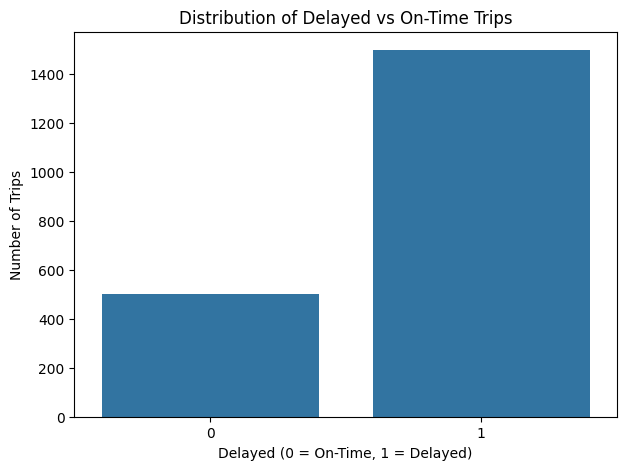

In [149]:
plt.figure(figsize=(7,5))
sns.countplot(data=df,x='delayed')
plt.title('Distribution of Delayed vs On-Time Trips')
plt.xlabel('Delayed (0 = On-Time, 1 = Delayed)')
plt.ylabel('Number of Trips')
plt.show()

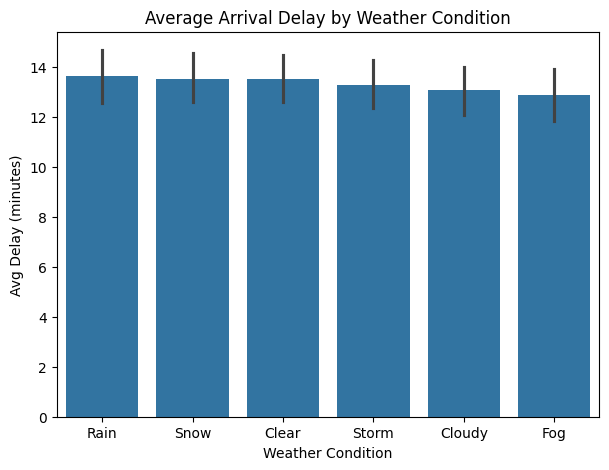

In [150]:
x=df.groupby('weather_condition')['actual_arrival_delay_min'].mean().sort_values(ascending=False)
plt.figure(figsize=(7,5))
sns.barplot(data=df,x='weather_condition',y='actual_arrival_delay_min',order=x.sort_values(ascending=False).index)
plt.title('Average Arrival Delay by Weather Condition')
plt.xlabel('Weather Condition')
plt.ylabel('Avg Delay (minutes)')
plt.show()

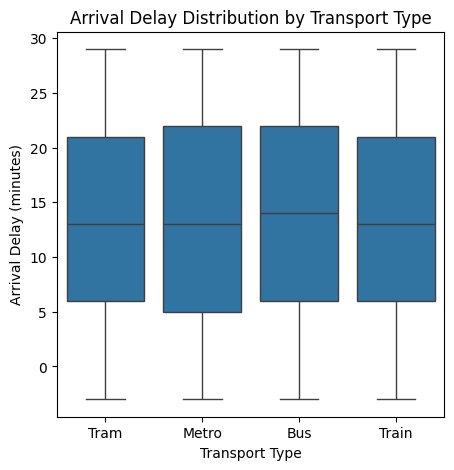

In [151]:
plt.figure(figsize=(5,5))
sns.boxplot(data=df,x='transport_type',y='actual_arrival_delay_min' )
plt.title('Arrival Delay Distribution by Transport Type')
plt.xlabel('Transport Type')
plt.ylabel('Arrival Delay (minutes)')
plt.show()

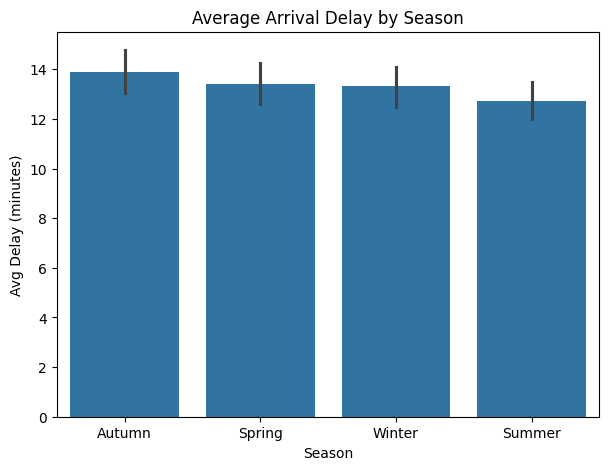

In [152]:
x=df.groupby('season')['actual_arrival_delay_min'].mean().sort_values(ascending=False)
plt.figure(figsize=(7,5))
sns.barplot(data=df,x='season',y='actual_arrival_delay_min',order=x.sort_values(ascending=False).index)
plt.title('Average Arrival Delay by Season')
plt.xlabel('Season')
plt.ylabel('Avg Delay (minutes)')
plt.show()

In [153]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 24 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   trip_id                     2000 non-null   str           
 1   date                        2000 non-null   datetime64[us]
 2   time                        2000 non-null   object        
 3   transport_type              2000 non-null   str           
 4   route_id                    2000 non-null   str           
 5   origin_station              2000 non-null   str           
 6   destination_station         2000 non-null   str           
 7   scheduled_departure         2000 non-null   str           
 8   scheduled_arrival           2000 non-null   str           
 9   actual_departure_delay_min  2000 non-null   int64         
 10  actual_arrival_delay_min    2000 non-null   int64         
 11  weather_condition           2000 non-null   str           
 12  tem